# *EDA*: Matriz de *features* en `data/02_intermediate`

**Pregunta que responde:** cómo está perfilada la matriz materializada por `build_features` (distribuciones, *missingness*, correlaciones y comparaciones entre símbolos) para informar decisiones aguas abajo de transformaciones causales y selección supervisada.

**No cubre:**
- definición ni evaluación de *targets* supervisados (eso vive en `02_features/02_evaluacion_etiquetado_targets.ipynb`),
- protocolo de selección de variables *intra-fold* (eso vive en `02_features/03_metodologia_seleccion_features.ipynb`),
- materialización ni aceptación del *dataset* supervisado (eso vive en `03_dataset_supervisado/01_evidencia_dataset_modelado.ipynb`).

**Alcance exploratorio**: cualquier escalado o normalización que aparezca aquí es **solo para visualización**. La normalización que alimenta al modelo se realiza con `fit` en *train* del *fold*, **nunca en este notebook**. Las cifras agregadas son descriptivas: no se reportan métricas de modelo ni se anuncia ningún *ranking* de *features*.

**Productos:** figura de cobertura (`fig_cobertura_fuentes_intra_simbolo_4h.png`, `.pdf`) bajo `reports/figures/features/`; CSV de extremos (`extreme_values_feature_detail.csv`, `extreme_values_family_summary.csv`) bajo `reports/eda/features/`.

## Secciones

0. Carga de Parquets y alineación de fuentes por símbolo (cobertura temporal intra-activo)
1. Resumen general por símbolo
2. *Missingness* (NaN fuera de *warm-up*)
3. Distribuciones por familia
4. Correlación/colinealidad
5. Comparación entre símbolos
6. Esquema de columnas entre símbolos
7. Valores extremos y traspaso al preprocesado *fold-aware*
8. Conclusiones: capa intermedia y selección de variables

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "config").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import numpy.ma as ma
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.features.multisource_backbone_contract import (
    OHLCV_BACKBONE_COLUMNS,
    DERIVATIVES_BACKBONE_VALUE_COLUMNS,
    ONCHAIN_BACKBONE_COLUMNS,
    MICROSTRUCTURE_BACKBONE_COLUMNS,
    SENTIMENT_BACKBONE_COLUMNS,
    WIKIPEDIA_BACKBONE_COLUMNS,
    GOOGLE_TRENDS_COLUMN_PREFIX,
)

INTERMEDIATE_DIR = ROOT / "data" / "02_intermediate"
EDA_DIR = ROOT / "reports" / "eda" / "features"
FIG_DIR = ROOT / "reports" / "figures" / "features"
EDA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root proyecto: {ROOT}")
print(f"Directorio intermedio: {INTERMEDIATE_DIR}")
print(f"Directorio EDA (CSV): {EDA_DIR}")
print(f"Directorio figuras: {FIG_DIR}")
print(f"Existe: {INTERMEDIATE_DIR.exists()}")

Root proyecto: /app
Directorio intermedio: /app/data/02_intermediate
Directorio EDA (CSV): /app/reports/eda/features
Directorio figuras: /app/reports/figures/features
Existe: True


## 0. Carga de Parquets

Tras listar y cargar los ficheros, la subsección **0.1** compara, **por cada símbolo**, en qué **fecha (UTC) empiezan y terminan** las distintas **fuentes** (familias: OHLCV, derivados, *on-chain*, etc.) a partir de donde hay **al menos un valor no nulo** en la rejilla 4h, y el retraso de cada fuente frente a la de inicio **más antiguo en ese mismo símbolo** (alineación intra-activo, no entre pares como BNB, BTC, etc.).


In [2]:
parquet_files = sorted(INTERMEDIATE_DIR.glob("*_features_4h.parquet")) if INTERMEDIATE_DIR.exists() else []
print(f"Parquets encontrados: {len(parquet_files)}")
for p in parquet_files:
    print(f"  {p.name}")

if not parquet_files:
    raise FileNotFoundError(
        f"No se encontraron Parquets en {INTERMEDIATE_DIR}. "
        "Ejecuta primero `python -m src.main features` para materializar."
    )

Parquets encontrados: 5
  bnbusdt_features_4h.parquet
  btcusdt_features_4h.parquet
  ethusdt_features_4h.parquet
  solusdt_features_4h.parquet
  xrpusdt_features_4h.parquet


In [3]:
dfs: dict[str, pd.DataFrame] = {}
for path in parquet_files:
    symbol = path.stem.replace("_features_4h", "").upper()
    df = pd.read_parquet(path)
    if not isinstance(df.index, pd.DatetimeIndex):
        if "timestamp" in df.columns:
            df = df.set_index("timestamp")
        df.index = pd.DatetimeIndex(df.index)
    dfs[symbol] = df
    print(f"{symbol}: {df.shape[0]} filas x {df.shape[1]} columnas, "
          f"{df.index.min()} -> {df.index.max()}")

symbols = sorted(dfs.keys())
print(f"\nSímbolos cargados: {symbols}")

BNBUSDT: 18222 filas x 127 columnas, 2017-11-06 00:00:00 -> 2026-02-28 20:00:00
BTCUSDT: 18707 filas x 127 columnas, 2017-08-17 04:00:00 -> 2026-02-28 20:00:00
ETHUSDT: 18707 filas x 127 columnas, 2017-08-17 04:00:00 -> 2026-02-28 20:00:00
SOLUSDT: 12167 filas x 127 columnas, 2020-08-11 04:00:00 -> 2026-02-28 20:00:00
XRPUSDT: 17146 filas x 127 columnas, 2018-05-04 08:00:00 -> 2026-02-28 20:00:00

Símbolos cargados: ['BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']


### 0.1 Inicio y fin de histórico **por fuente y por símbolo**

Para cada símbolo y cada **fuente** (columnas de la misma familia, función `classify_column` en la celda de código de abajo), se toma el **primer y último** instante (UTC) en el que la fuente tiene **algún dato no nulo** (no el índice completo de la hoja, que en todos los casos sigue la rejilla 4h). El **retraso (días)** mide la diferencia entre el inicio de esa fuente y el inicio **más antiguo de cualquier otra fuente con datos en ese mismo símbolo** (alineación **intra-activo**, no entre activos). Fuentes sin un solo dato en todo el rango: fila con inicio nulo; no se incluyen en el gráfico de barras.


,simbolo,fuente,inicio_ts_utc,fin_ts_utc,filas_con_dato,span_dias,retraso_vs_inicio_mas_antiguo_mismo_simbolo_d
0,BNBUSDT,ohlcv,2017-11-06 00:00:00,2026-02-28 20:00:00,18222,3036.833333,0.000000
1,BNBUSDT,derivatives,2022-01-01 00:00:00,2026-02-28 20:00:00,9120,1519.833333,1517.000000
2,BNBUSDT,onchain,2020-09-01 00:00:00,2026-02-28 20:00:00,12042,2006.833333,1030.000000
3,BNBUSDT,microstructure,2017-11-06 00:00:00,2026-02-28 20:00:00,18222,3036.833333,0.000000
4,BNBUSDT,sentiment,2017-11-06 00:00:00,2026-02-28 20:00:00,18222,3036.833333,0.000000
5,BNBUSDT,google_trends,2017-11-06 00:00:00,2026-02-28 20:00:00,18222,3036.833333,0.000000
6,BNBUSDT,wikipedia,2018-03-17 00:00:00,2026-02-28 20:00:00,17436,2905.833333,131.000000
7,BNBUSDT,technical,2017-11-06 00:00:00,2026-02-28 20:00:00,18222,3036.833333,0.000000
8,BTCUSDT,ohlcv,2017-08-17 04:00:00,2026-02-28 20:00:00,18707,3117.666667,0.000000
9,BTCUSDT,derivatives,2022-01-01 00:00:00,2026-02-28 20:00:00,9120,1519.833333,1597.833333


Figura lista para TFG (PNG 300 dpi + PDF vectorial):
  /app/reports/figures/features/fig_cobertura_fuentes_intra_simbolo_4h.png
  /app/reports/figures/features/fig_cobertura_fuentes_intra_simbolo_4h.pdf


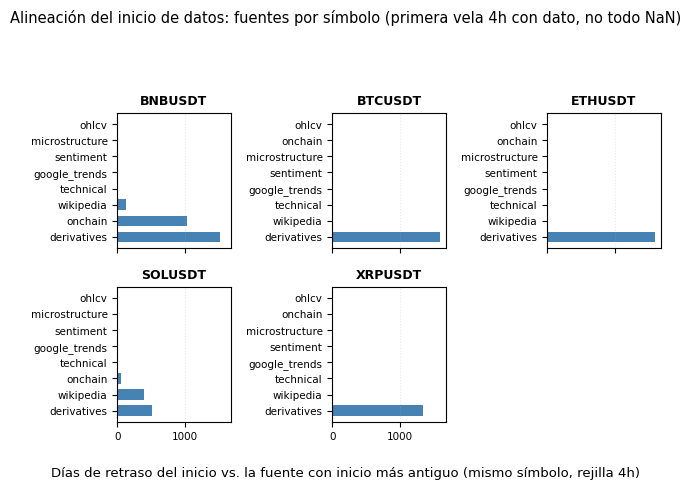

In [4]:
from collections import defaultdict

def classify_column(col: str) -> str:
    """Asigna familia o fuente según prefijo/nombre (misma regla que en la sección 1)"""
    if col in OHLCV_BACKBONE_COLUMNS:
        return "ohlcv"
    if col in DERIVATIVES_BACKBONE_VALUE_COLUMNS or col.startswith(("funding_", "oi_", "ls_")):
        return "derivatives"
    if col in ONCHAIN_BACKBONE_COLUMNS or col.startswith("oc_"):
        return "onchain"
    if col in MICROSTRUCTURE_BACKBONE_COLUMNS or col.startswith("ms_"):
        return "microstructure"
    if col in SENTIMENT_BACKBONE_COLUMNS or col.startswith(("reddit_", "guardian_", "nytimes_")):
        return "sentiment"
    if col in WIKIPEDIA_BACKBONE_COLUMNS or col == "wiki_views":
        return "wikipedia"
    if col.startswith(GOOGLE_TRENDS_COLUMN_PREFIX):
        return "google_trends"
    if col.startswith("__source_ts__"):
        return "_lineage"
    return "technical"


FAMILIES_ORDER = [
    "ohlcv",
    "derivatives",
    "onchain",
    "microstructure",
    "sentiment",
    "google_trends",
    "wikipedia",
    "technical",
]


def columns_by_family(df: pd.DataFrame) -> dict[str, list[str]]:
    m: dict[str, list[str]] = defaultdict(list)
    for c in df.columns:
        f = classify_column(c)
        if f == "_lineage":
            continue
        m[f].append(c)
    return dict(m)


def source_observed_span(
    df: pd.DataFrame, cols: list[str]
) -> tuple[object, object, int, float]:
    """Primer/último instante con al menos un no-nulo, filas con dato, span en días (float)"""
    if not cols:
        return pd.NaT, pd.NaT, 0, float("nan")
    sub = df[cols]
    mask = sub.notna().any(axis=1)
    if not mask.any():
        return pd.NaT, pd.NaT, 0, float("nan")
    t_idx = df.index[mask]
    t0, t1 = t_idx.min(), t_idx.max()
    n = int(mask.sum())
    span_days = (t1 - t0).total_seconds() / 86400.0
    return t0, t1, n, span_days


cobertura_por_fuente: list[dict] = []
for sym in symbols:
    dfi = dfs[sym]
    fam_map = columns_by_family(dfi)
    starts_valid: list[pd.Timestamp] = []
    t0t1: dict[str, tuple] = {}
    for fam in FAMILIES_ORDER:
        cols = fam_map.get(fam, [])
        t0, t1, n_rows, sp = source_observed_span(dfi, cols)
        t0t1[fam] = (t0, t1, n_rows, sp)
        if pd.notna(t0):
            starts_valid.append(t0)  # type: ignore[arg-type]
    if starts_valid:
        t_ref = min(starts_valid)  # inicio de fuente más antiguo en este símbolo
    else:
        t_ref = None
    for fam in FAMILIES_ORDER:
        t0, t1, n_rows, sp = t0t1[fam]
        if t_ref is not None and pd.notna(t0):
            retraso = (t0 - t_ref).total_seconds() / 86400.0
        else:
            retraso = float("nan")
        cobertura_por_fuente.append(
            {
                "simbolo": sym,
                "fuente": fam,
                "inicio_ts_utc": t0,
                "fin_ts_utc": t1,
                "filas_con_dato": n_rows,
                "span_dias": sp,
                "retraso_vs_inicio_mas_antiguo_mismo_simbolo_d": retraso,
            }
        )

cobertura_df = (
    pd.DataFrame(cobertura_por_fuente)
    .assign(_k=lambda d: d["fuente"].map({f: i for i, f in enumerate(FAMILIES_ORDER)}))
    .sort_values(["simbolo", "_k"])
    .drop(columns="_k")
    .reset_index(drop=True)
)
display(cobertura_df)

# Figura con exportación para memoria: malla 2×3 (2 filas × 3 columnas)
n = len(symbols)
N_FILAS, N_COLS = 2, 3
N_CELDAS = N_FILAS * N_COLS
if n > N_CELDAS:
    print(
        f"Aviso: la malla es 2×3 (6 paneles). Se representan los primeros {N_CELDAS} de {n} símbolos."
    )
    symbols_malla: list[str] = list(symbols)[:N_CELDAS]
else:
    symbols_malla = list(symbols)
# Ancho total ~ página; altura acomodada a dos filas
w_in, h_in = 6.6, 4.85
fig, axes_2d = plt.subplots(N_FILAS, N_COLS, figsize=(w_in, h_in), sharex=True)
axes_flat = np.asarray(axes_2d).ravel()
for j in range(N_CELDAS):
    ax = axes_flat[j]
    if j >= len(symbols_malla):
        ax.set_visible(False)
        continue
    sym = symbols_malla[j]
    p = (
        cobertura_df[(cobertura_df["simbolo"] == sym)]
        .dropna(subset=["inicio_ts_utc"])
        .copy()
    )
    if p.empty:
        ax.set_title(
            f"{sym} (ninguna fila con dato en fuentes mapeadas)", fontsize=9, fontweight="bold"
        )
    else:
        p = p.sort_values("retraso_vs_inicio_mas_antiguo_mismo_simbolo_d", ascending=True)
        x = p["retraso_vs_inicio_mas_antiguo_mismo_simbolo_d"].to_numpy()
        y = p["fuente"].to_numpy()
        ax.barh(y, x, color="steelblue", height=0.65)
        ax.set_title(sym, fontsize=9, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3, linestyle=":")
    ax.tick_params(axis="both", which="major", labelsize=7.5)
fig.supxlabel(
    "Días de retraso del inicio vs. la fuente con inicio más antiguo (mismo símbolo, rejilla 4h)",
    fontsize=9.5,
)
fig.suptitle(
    "Alineación del inicio de datos: fuentes por símbolo (primera vela 4h con dato, no todo NaN)",
    fontsize=10.5,
)
plt.tight_layout(rect=(0, 0, 1, 0.9))

out_base = FIG_DIR / "fig_cobertura_fuentes_intra_simbolo_4h"
out_png = out_base.with_suffix(".png")
out_pdf = out_base.with_suffix(".pdf")
fig.savefig(
    out_png, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none", pad_inches=0.04
)
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white", edgecolor="none", pad_inches=0.04)
print("Figura lista:")
print(f"  {out_png.resolve()}")
print(f"  {out_pdf.resolve()}")
plt.show()


## 1. Resumen general por símbolo

In [5]:
# Necesita `classify_column` de la celda de cobertura por fuente (sección 0 arriba)
ref_symbol = symbols[0]
ref_df = dfs[ref_symbol]
col_families = {col: classify_column(col) for col in ref_df.columns}
family_counts = pd.Series(col_families).value_counts().sort_index()
print(f"Columnas por familia ({ref_symbol}):")
print(family_counts.to_string())

Columnas por familia (BNBUSDT):
derivatives       27
google_trends      8
microstructure    11
ohlcv              7
onchain           10
sentiment          6
technical         56
wikipedia          2


In [6]:
summary_rows = []
for sym, df in dfs.items():
    numeric = df.select_dtypes(include="number")
    summary_rows.append({
        "symbol": sym,
        "rows": len(df),
        "columns": len(df.columns),
        "numeric_columns": len(numeric.columns),
        "nan_total": int(numeric.isna().sum().sum()),
        "nan_pct": round(float(numeric.isna().mean().mean()) * 100, 2),
        "inf_count": int(np.isinf(numeric.values).sum()) if numeric.size > 0 else 0,
        "start": str(df.index.min()),
        "end": str(df.index.max()),
    })

summary_df = pd.DataFrame(summary_rows).set_index("symbol")
summary_df

,rows,columns,numeric_columns,nan_total,nan_pct,inf_count,start,end
symbol,,,,,,,,
BNBUSDT,18222,127,121,387343,17.57,0,2017-11-06 00:00:00,2026-02-28 20:00:00
BTCUSDT,18707,127,121,332411,14.69,0,2017-08-17 04:00:00,2026-02-28 20:00:00
ETHUSDT,18707,127,121,334073,14.76,0,2017-08-17 04:00:00,2026-02-28 20:00:00
SOLUSDT,12167,127,121,132112,8.97,0,2020-08-11 04:00:00,2026-02-28 20:00:00
XRPUSDT,17146,127,121,283537,13.67,0,2018-05-04 08:00:00,2026-02-28 20:00:00


## 2. *Missingness* (NaN fuera de *warm-up*)

El *warm-up* genera NaN esperados en las primeras filas. Aquí analizamos NaN **después** de las primeras 50 barras (>= 200 h de *warm-up*) para detectar fuentes rotas o cobertura insuficiente.

In [7]:
WARMUP_SKIP = 50

def missingness_by_family(df: pd.DataFrame, warmup_skip: int = WARMUP_SKIP) -> pd.DataFrame:
    post_warmup = df.iloc[warmup_skip:]
    numeric = post_warmup.select_dtypes(include="number")
    nan_pct = numeric.isna().mean() * 100
    families = pd.Series({c: classify_column(c) for c in numeric.columns})
    result = pd.DataFrame({"nan_pct": nan_pct, "family": families})
    return result.sort_values(["family", "nan_pct"], ascending=[True, False])


for sym in symbols:
    miss = missingness_by_family(dfs[sym])
    problematic = miss[miss["nan_pct"] > 10]
    print(f"\n--- {sym}: columnas con >10% NaN post warm-up ---")
    if problematic.empty:
        print("  Ninguna (todas <= 10%)")
    else:
        print(problematic.to_string())


--- BNBUSDT: columnas con >10% NaN post warm-up ---
                                     nan_pct       family
fr_mark_price                      71.879815  derivatives
funding_rate_zscore_rolling        53.428351  derivatives
funding_regime_flag                53.428351  derivatives
ls_global_long                     50.423729  derivatives
ls_global_short                    50.423729  derivatives
ls_global_ratio                    50.423729  derivatives
ls_top_long                        50.423729  derivatives
ls_top_short                       50.423729  derivatives
ls_top_ratio                       50.423729  derivatives
ls_top_position_long               50.423729  derivatives
ls_top_position_short              50.423729  derivatives
ls_top_position_ratio              50.423729  derivatives
ls_global_imbalance                50.423729  derivatives
ls_top_account_imbalance           50.423729  derivatives
ls_top_position_imbalance          50.423729  derivatives
ls_spread_top_vs_gl

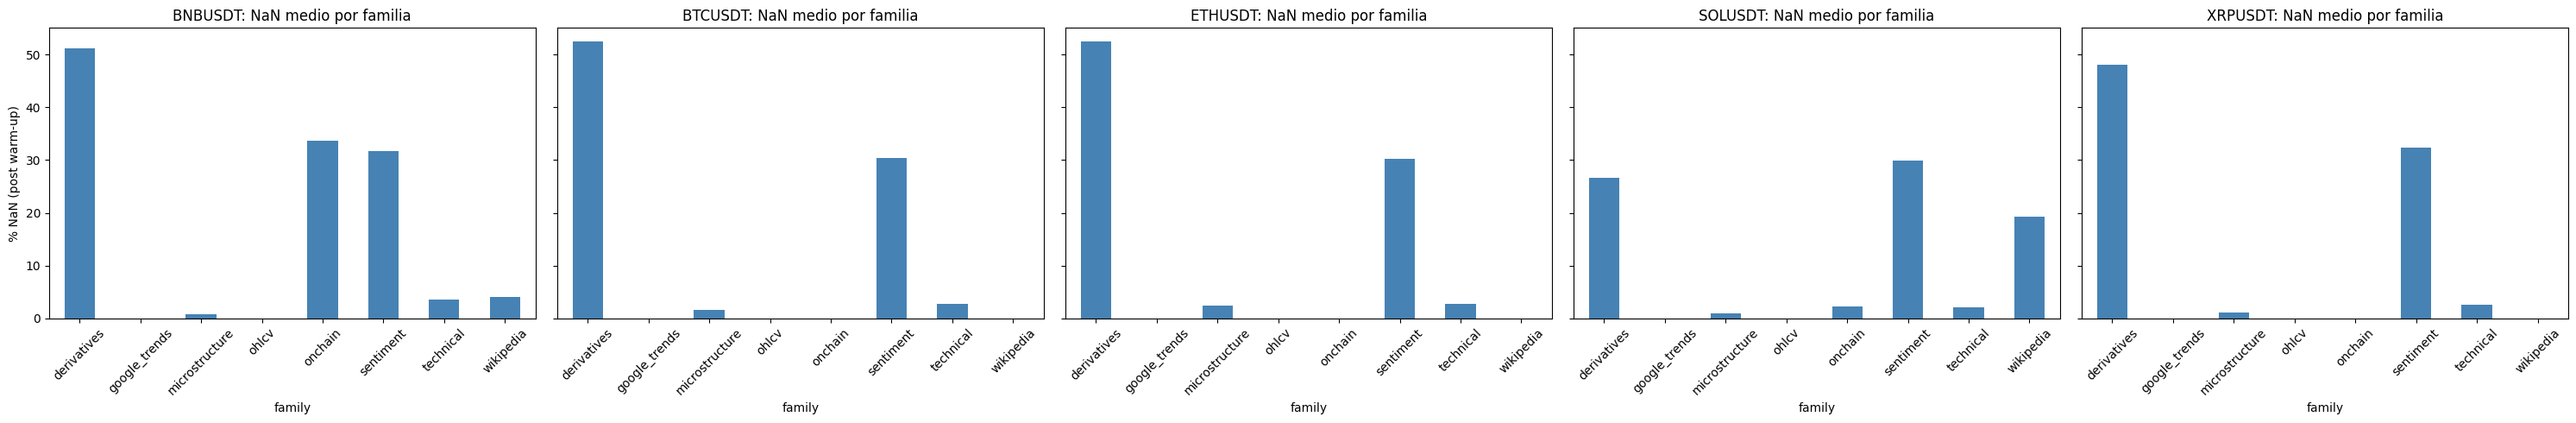

In [8]:
fig, axes = plt.subplots(1, len(symbols), figsize=(6 * len(symbols), 5), sharey=True)
if len(symbols) == 1:
    axes = [axes]

for ax, sym in zip(axes, symbols):
    miss = missingness_by_family(dfs[sym])
    miss_by_fam = miss.groupby("family")["nan_pct"].mean()
    miss_by_fam.plot.bar(ax=ax, color="steelblue")
    ax.set_title(f"{sym}: NaN medio por familia")
    ax.set_ylabel("% NaN (post warm-up)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3. Distribuciones por familia

*Boxplots* estandarizados solo para visualización (*z-score* exploratorio sobre todo el histórico; **no** es el escalado del modelo).

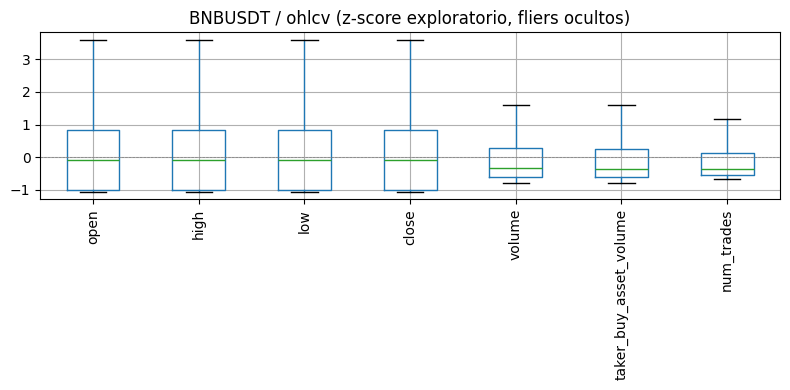

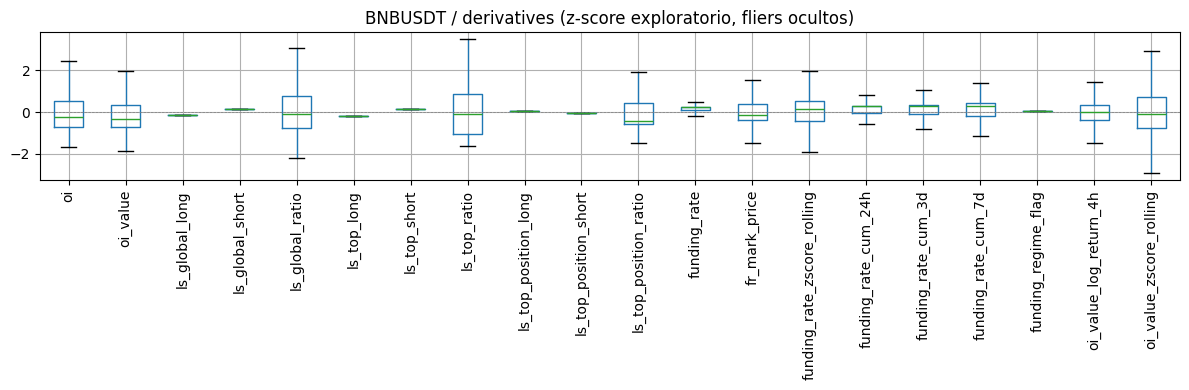

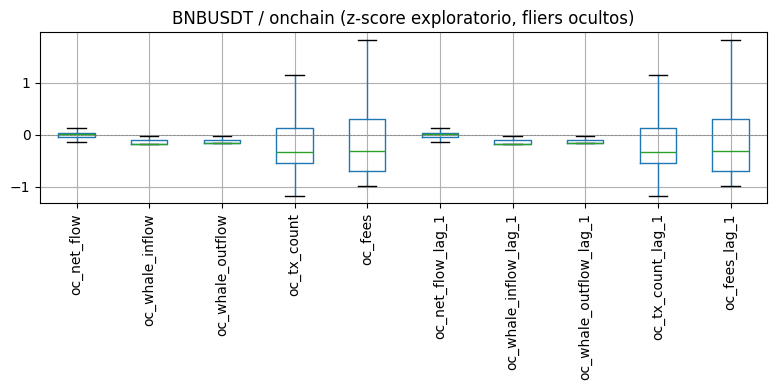

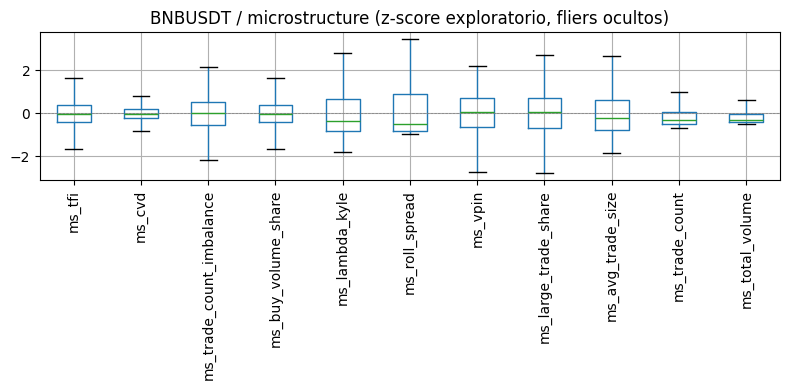

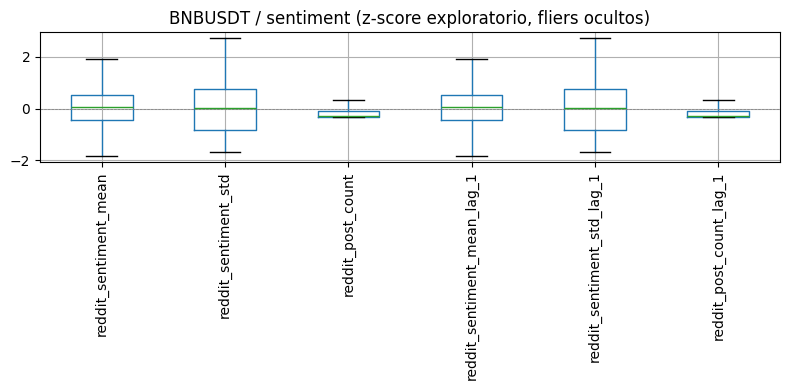

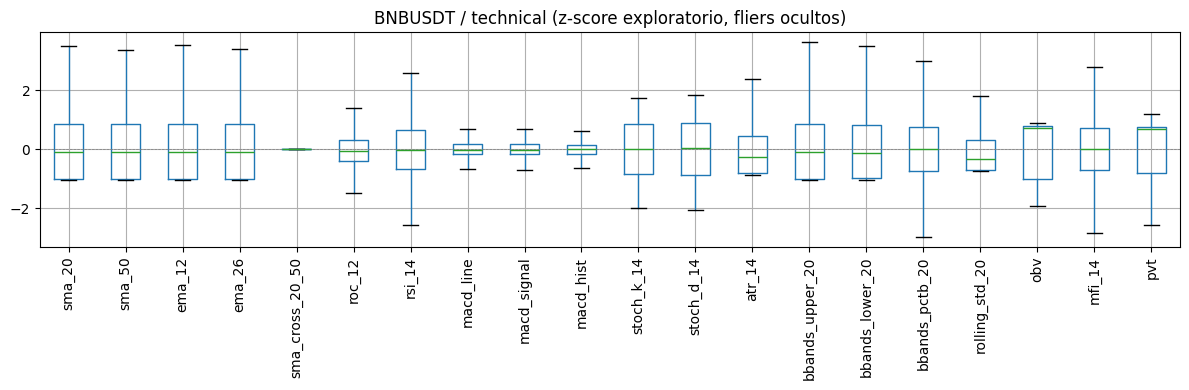

In [9]:
FAMILIES_TO_PLOT = ["ohlcv", "derivatives", "onchain", "microstructure", "sentiment", "technical"]

def plot_family_boxplots(df: pd.DataFrame, symbol: str, family: str, max_cols: int = 20) -> None:
    cols = [c for c in df.select_dtypes(include="number").columns if classify_column(c) == family]
    if not cols:
        return
    cols = cols[:max_cols]
    data = df[cols].iloc[WARMUP_SKIP:]
    # z-score SOLO para visualización
    scaled = (data - data.mean()) / data.std().replace(0, np.nan)
    fig, ax = plt.subplots(figsize=(max(8, len(cols) * 0.6), 4))
    scaled.boxplot(ax=ax, vert=True, rot=90, showfliers=False)
    ax.set_title(f"{symbol} / {family} (z-score exploratorio, fliers ocultos)")
    ax.axhline(0, color="gray", ls="--", lw=0.5)
    plt.tight_layout()
    plt.show()


for family in FAMILIES_TO_PLOT:
    plot_family_boxplots(ref_df, ref_symbol, family)

## 4. Correlación / colinealidad

Matriz de correlación por familia para el símbolo de referencia. Se destacan pares con `|r| > 0.90` como candidatos a poda por colinealidad antes del modelado supervisado.

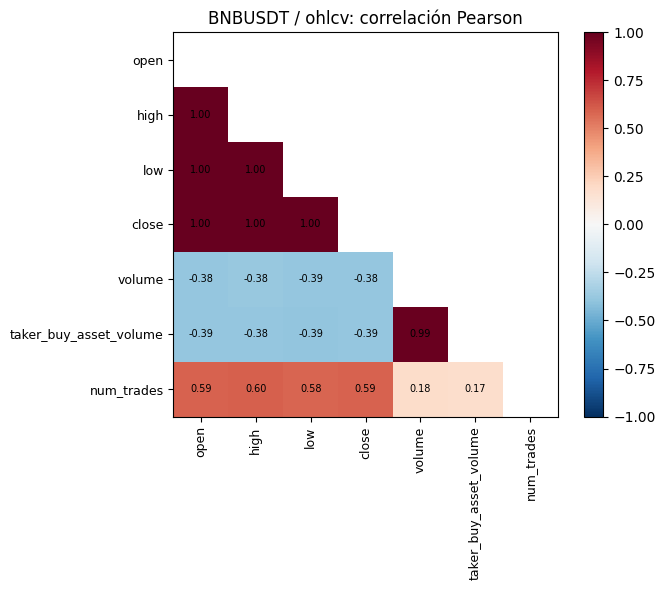

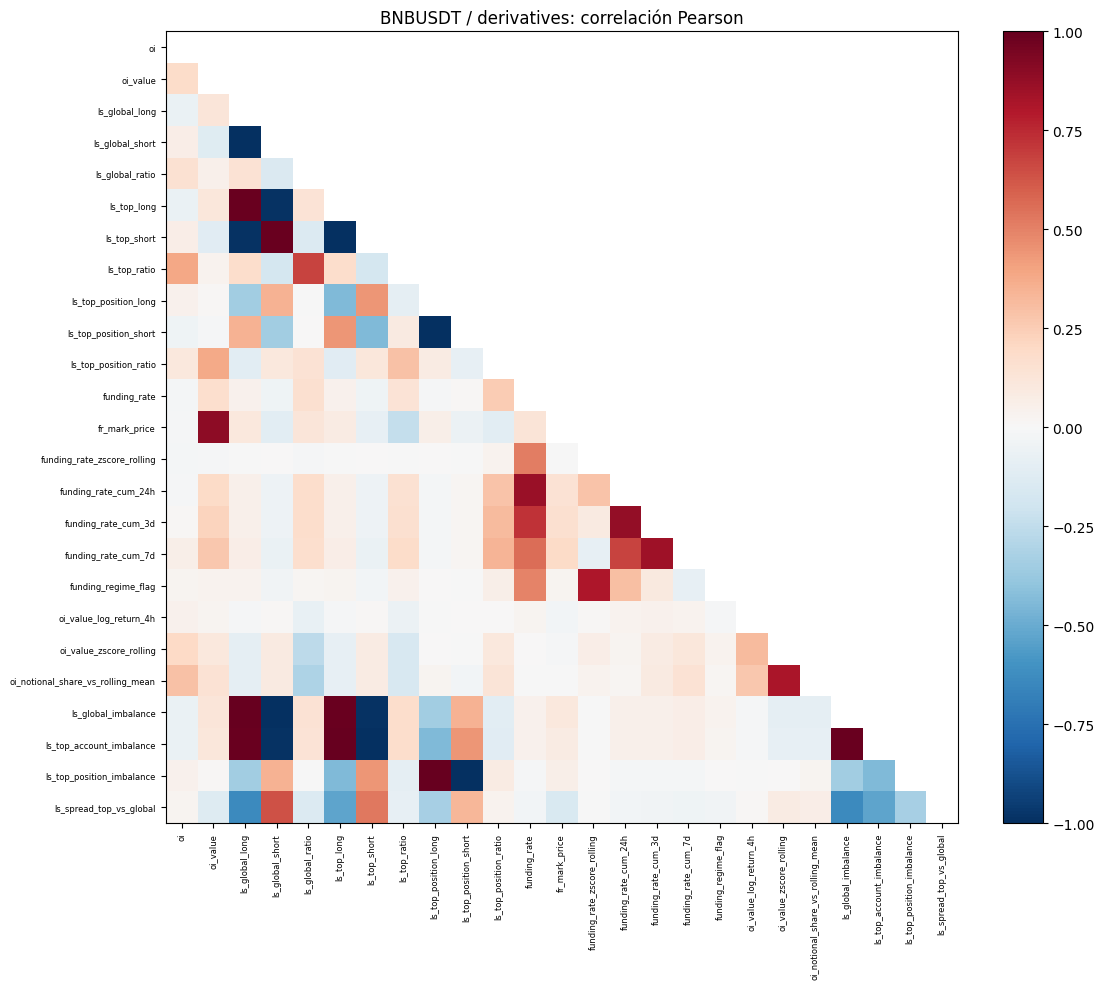

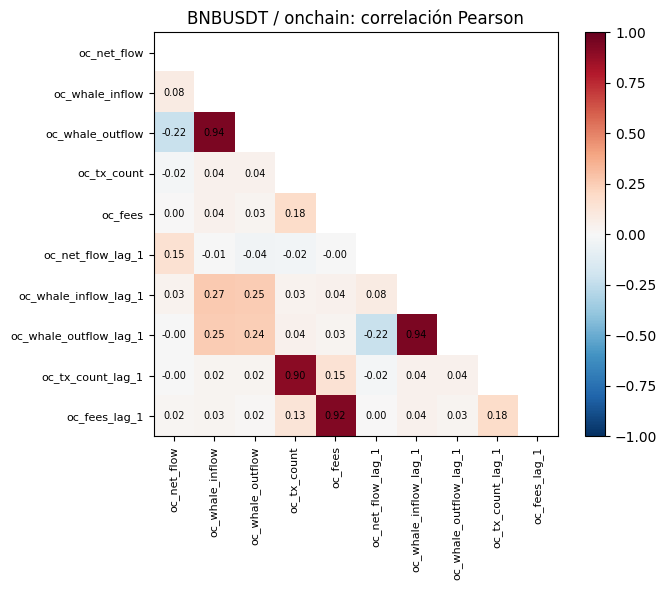

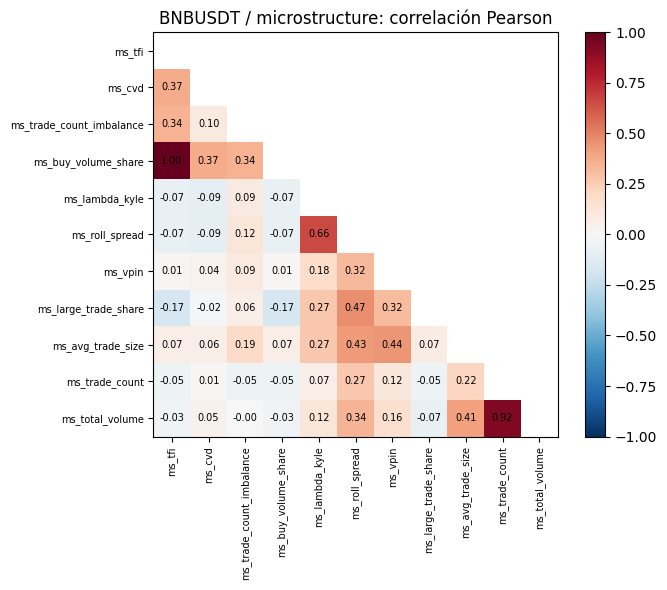

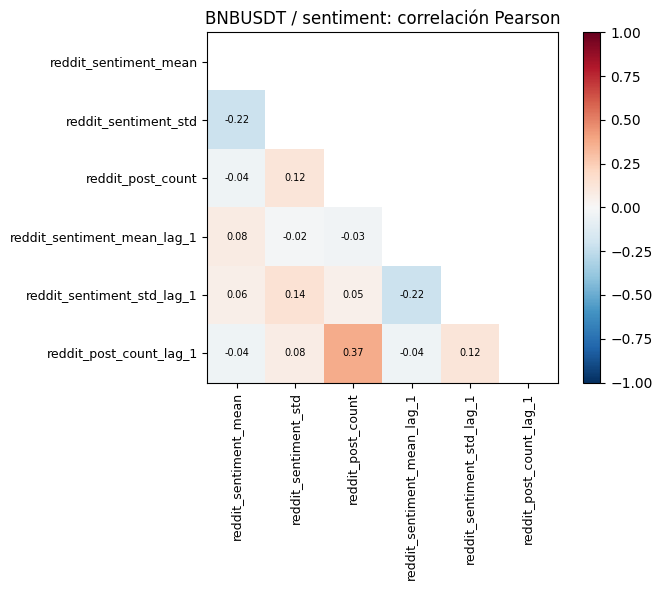

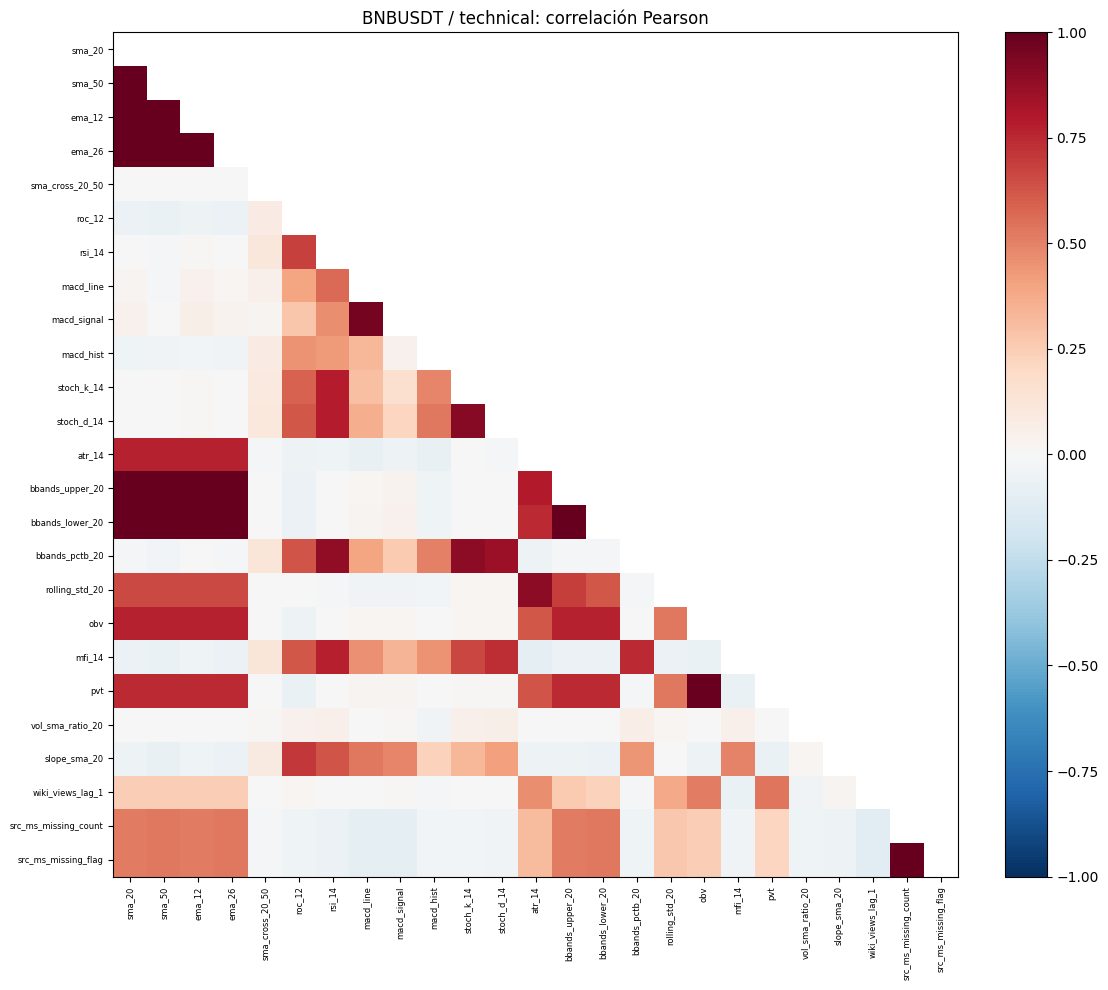

In [10]:
def correlation_heatmap(df: pd.DataFrame, symbol: str, family: str, max_cols: int = 25) -> None:
    cols = [c for c in df.select_dtypes(include="number").columns if classify_column(c) == family]
    if len(cols) < 2:
        return
    cols = cols[:max_cols]
    corr = df[cols].iloc[WARMUP_SKIP:].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    corr_arr = corr.to_numpy(dtype=float)
    corr_masked = ma.masked_where(mask, corr_arr)
    fig, ax = plt.subplots(figsize=(max(8, len(cols) * 0.5), max(6, len(cols) * 0.4)))
    im = ax.imshow(corr_masked, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
    ax.set_xticks(np.arange(len(cols)))
    ax.set_yticks(np.arange(len(cols)))
    fs = max(6, min(9, 80 // max(len(cols), 1)))
    ax.set_xticklabels(cols, rotation=90, fontsize=fs)
    ax.set_yticklabels(cols, fontsize=fs)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if len(cols) <= 15:
        for i in range(len(cols)):
            for j in range(len(cols)):
                if not mask[i, j]:
                    val = corr_arr[i, j]
                    if np.isfinite(val):
                        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"{symbol} / {family}: correlación Pearson")
    plt.tight_layout()
    plt.show()


for family in FAMILIES_TO_PLOT:
    correlation_heatmap(ref_df, ref_symbol, family)

In [11]:
def highly_correlated_pairs(
    df: pd.DataFrame, threshold: float = 0.90, warmup_skip: int = WARMUP_SKIP
) -> pd.DataFrame:
    """Pares con |correlación| > threshold (post warm-up)"""
    numeric = df.select_dtypes(include="number").iloc[warmup_skip:]
    corr = numeric.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    pairs = corr.where(mask).stack().reset_index()
    pairs.columns = ["col_a", "col_b", "correlation"]
    pairs["abs_corr"] = pairs["correlation"].abs()
    high = pairs[pairs["abs_corr"] > threshold].sort_values("abs_corr", ascending=False)
    high["family_a"] = high["col_a"].map(classify_column)
    high["family_b"] = high["col_b"].map(classify_column)
    return high.reset_index(drop=True)


print(f"Pares altamente correlacionados (|r| > 0.90) en {ref_symbol}:")
hc = highly_correlated_pairs(ref_df)
if hc.empty:
    print("  Ninguno.")
else:
    print(hc[["col_a", "col_b", "correlation", "family_a", "family_b"]].to_string(index=False))

Pares altamente correlacionados (|r| > 0.90) en BNBUSDT:
                          col_a                      col_b  correlation       family_a       family_b
     src_deriv_ls_missing_count  src_deriv_ls_missing_flag     1.000000      technical      technical
          ls_top_position_short  ls_top_position_imbalance    -1.000000    derivatives    derivatives
                 ls_global_long            ls_global_short    -1.000000    derivatives    derivatives
           ls_top_position_long  ls_top_position_imbalance     1.000000    derivatives    derivatives
                   ls_top_short   ls_top_account_imbalance    -1.000000    derivatives    derivatives
                    ls_top_long   ls_top_account_imbalance     1.000000    derivatives    derivatives
                ls_global_short        ls_global_imbalance    -1.000000    derivatives    derivatives
                 ls_global_long        ls_global_imbalance     1.000000    derivatives    derivatives
     src_deriv_oi_missing

## 5. Comparación entre símbolos

Para las columnas comunes, comparamos estadísticos descriptivos entre símbolos. Diferencias grandes pueden indicar regímenes distintos o problemas de cobertura.

In [12]:
if len(symbols) > 1:
    common_cols = set(dfs[symbols[0]].columns)
    for sym in symbols[1:]:
        common_cols &= set(dfs[sym].columns)
    common_numeric = sorted(
        c for c in common_cols
        if dfs[symbols[0]][c].dtype.kind in ("f", "i") and not c.startswith("__")
    )
    print(f"Columnas numéricas comunes: {len(common_numeric)}")

    stats_rows = []
    for sym in symbols:
        desc = dfs[sym][common_numeric].iloc[WARMUP_SKIP:].describe().T
        desc["symbol"] = sym
        stats_rows.append(desc)
    stats_all = pd.concat(stats_rows)

    pivot_mean = stats_all.pivot_table(index=stats_all.index.get_level_values(0),
                                       columns="symbol", values="mean")
    pivot_std = stats_all.pivot_table(index=stats_all.index.get_level_values(0),
                                      columns="symbol", values="std")

    cv_across = pivot_std.std(axis=1) / (pivot_mean.mean(axis=1).abs() + 1e-12)
    divergent = cv_across.sort_values(ascending=False).head(15)
    print("\nTop 15 columnas con mayor variabilidad entre símbolos (CV de medias):")
    print(divergent.to_string())
else:
    print("Solo un símbolo cargado; comparación omitida.")

Columnas numéricas comunes: 117

Top 15 columnas con mayor variabilidad entre símbolos (CV de medias):
macd_hist                 7473.311127
funding_x_oi_change        437.410853
oc_net_flow                 69.629530
oc_net_flow_lag_1           69.614188
oi_value_log_return_4h      63.926507
macd_line                   53.266991
macd_signal                 50.138175
sma_cross_20_50             36.230650
funding_x_ls_spread         11.045478
ms_roll_spread               9.619111
funding_rate                 9.423311
ms_cvd                       9.415246
ms_tfi                       9.001572
oc_whale_outflow_lag_1       8.793624
oc_whale_outflow             8.793346


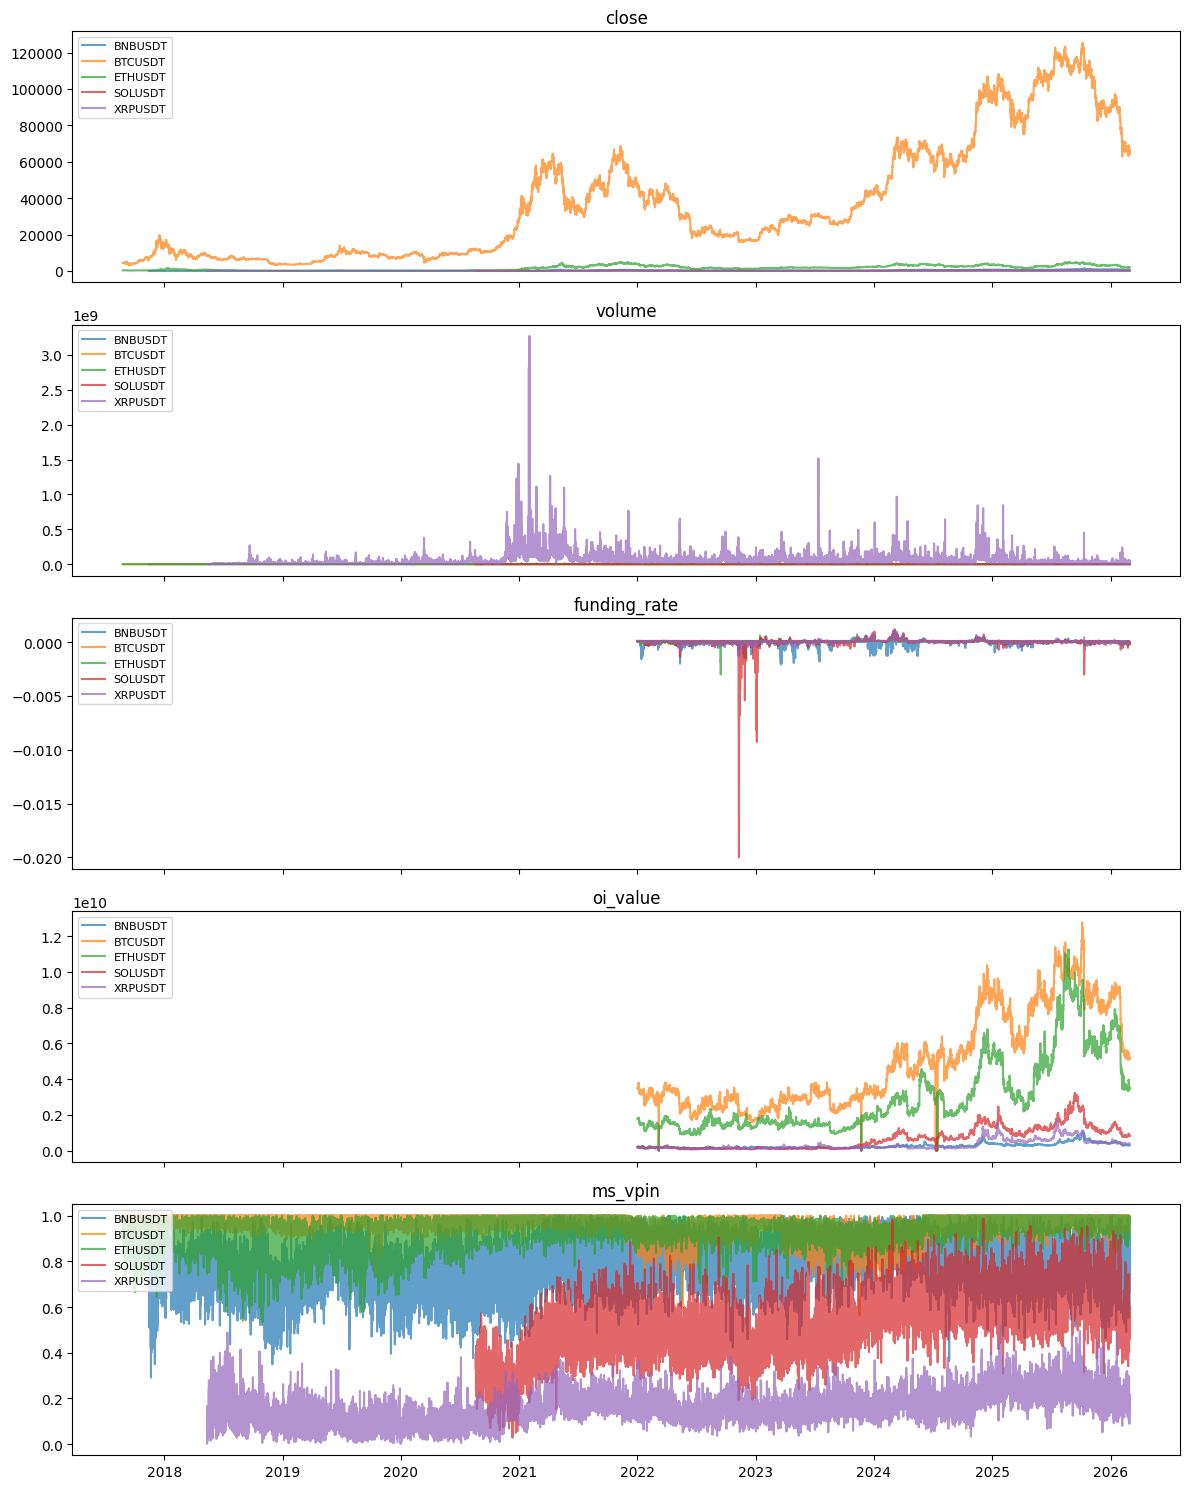

In [13]:
if len(symbols) > 1:
    sample_cols = ["close", "volume", "funding_rate", "oi_value", "ms_vpin"]
    sample_cols = [c for c in sample_cols if c in common_numeric]

    if sample_cols:
        fig, axes = plt.subplots(len(sample_cols), 1, figsize=(12, 3 * len(sample_cols)), sharex=True)
        if len(sample_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, sample_cols):
            for sym in symbols:
                series = dfs[sym][col].iloc[WARMUP_SKIP:]
                ax.plot(series.index, series.values, label=sym, alpha=0.7)
            ax.set_title(col)
            ax.legend(loc="upper left", fontsize=8)
        plt.tight_layout()
        plt.show()

## 6. Esquema de columnas: estabilidad entre símbolos

In [14]:
if len(symbols) > 1:
    ref_cols = set(dfs[symbols[0]].columns)
    for sym in symbols[1:]:
        other_cols = set(dfs[sym].columns)
        only_ref = ref_cols - other_cols
        only_other = other_cols - ref_cols
        if only_ref or only_other:
            print(f"{symbols[0]} vs {sym}:")
            if only_ref:
                print(f"  Solo en {symbols[0]}: {sorted(only_ref)}")
            if only_other:
                print(f"  Solo en {sym}: {sorted(only_other)}")
        else:
            print(f"{symbols[0]} vs {sym}: esquema idéntico.")
else:
    print("Solo un símbolo; comparación de esquema omitida.")

BNBUSDT vs BTCUSDT:
  Solo en BNBUSDT: ['gt_bnb', 'gt_bnb_imputed', 'gt_bnb_imputed_lag_1', 'gt_bnb_lag_1', 'gt_bnb_price', 'gt_bnb_price_imputed', 'gt_bnb_price_imputed_lag_1', 'gt_bnb_price_lag_1']
  Solo en BTCUSDT: ['gt_bitcoin', 'gt_bitcoin_imputed', 'gt_bitcoin_imputed_lag_1', 'gt_bitcoin_lag_1', 'gt_bitcoin_price', 'gt_bitcoin_price_imputed', 'gt_bitcoin_price_imputed_lag_1', 'gt_bitcoin_price_lag_1']
BNBUSDT vs ETHUSDT:
  Solo en BNBUSDT: ['gt_bnb', 'gt_bnb_imputed', 'gt_bnb_imputed_lag_1', 'gt_bnb_lag_1', 'gt_bnb_price', 'gt_bnb_price_imputed', 'gt_bnb_price_imputed_lag_1', 'gt_bnb_price_lag_1']
  Solo en ETHUSDT: ['gt_ethereum', 'gt_ethereum_imputed', 'gt_ethereum_imputed_lag_1', 'gt_ethereum_lag_1', 'gt_ethereum_price', 'gt_ethereum_price_imputed', 'gt_ethereum_price_imputed_lag_1', 'gt_ethereum_price_lag_1']
BNBUSDT vs SOLUSDT:
  Solo en BNBUSDT: ['gt_bnb', 'gt_bnb_imputed', 'gt_bnb_imputed_lag_1', 'gt_bnb_lag_1', 'gt_bnb_price', 'gt_bnb_price_imputed', 'gt_bnb_price_impute

## 7. Valores extremos y traspaso al preprocesado *fold-aware*

Esta sección cubre un hueco metodológico del *EDA*: no decide eliminar observaciones ni ajustar transformaciones sobre todo el histórico, pero cuantifica si la matriz intermedia contiene colas fuertes o valores extremos por símbolo y familia de variables.

La lectura debe ser descriptiva. En modelado, el tratamiento efectivo de extremos se aplica dentro de cada *fold* mediante pasos ajustados solo en *train*, como escalado robusto y *clipping* por cuantiles. Por tanto, aquí no se recalibran reglas de producción ni se usa información del tramo de evaluación para fijar límites; solo se deja evidencia de que el problema existe y de que debe trasladarse al preprocesado *fold-aware*.

In [15]:
EXTREME_MIN_OBS = 100
ROBUST_Z_THRESHOLD = 6.0


def summarize_extreme_values(
    df: pd.DataFrame,
    symbol: str,
    *,
    warmup_skip: int = WARMUP_SKIP,
    min_obs: int = EXTREME_MIN_OBS,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    numeric_cols = [
        c
        for c in df.select_dtypes(include="number").columns
        if not str(c).startswith("__")
    ]

    for col in numeric_cols:
        series = (
            df[col]
            .iloc[warmup_skip:]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        if len(series) < min_obs:
            continue

        q01, q05, q25, q50, q75, q95, q99 = series.quantile(
            [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        )
        iqr = q75 - q25
        if pd.isna(iqr) or iqr == 0:
            tukey_low = np.nan
            tukey_high = np.nan
            iqr_outlier_pct = 0.0
        else:
            tukey_low = q25 - 1.5 * iqr
            tukey_high = q75 + 1.5 * iqr
            iqr_outlier_pct = float(((series < tukey_low) | (series > tukey_high)).mean() * 100)

        mad = float((series - q50).abs().median())
        if mad > 0:
            robust_z = 0.6745 * (series - q50) / mad
            robust_z_gt_threshold_pct = float((robust_z.abs() > ROBUST_Z_THRESHOLD).mean() * 100)
            max_abs_robust_z = float(robust_z.abs().max())
        else:
            robust_z_gt_threshold_pct = 0.0
            max_abs_robust_z = 0.0

        rows.append(
            {
                "symbol": symbol,
                "feature": col,
                "family": classify_column(col),
                "n_obs": int(len(series)),
                "q01": float(q01),
                "q05": float(q05),
                "median": float(q50),
                "q95": float(q95),
                "q99": float(q99),
                "iqr": float(iqr) if pd.notna(iqr) else np.nan,
                "tukey_low": float(tukey_low) if pd.notna(tukey_low) else np.nan,
                "tukey_high": float(tukey_high) if pd.notna(tukey_high) else np.nan,
                "iqr_outlier_pct": iqr_outlier_pct,
                "robust_z_gt_6_pct": robust_z_gt_threshold_pct,
                "max_abs_robust_z": max_abs_robust_z,
            }
        )

    return pd.DataFrame(rows)


extreme_detail_df = pd.concat(
    [summarize_extreme_values(df, sym) for sym, df in dfs.items()],
    ignore_index=True,
)

extreme_family_summary_df = (
    extreme_detail_df
    .groupby(["symbol", "family"], as_index=False)
    .agg(
        n_features=("feature", "nunique"),
        median_iqr_outlier_pct=("iqr_outlier_pct", "median"),
        p95_iqr_outlier_pct=("iqr_outlier_pct", lambda s: s.quantile(0.95)),
        median_robust_z_gt_6_pct=("robust_z_gt_6_pct", "median"),
        max_robust_z_gt_6_pct=("robust_z_gt_6_pct", "max"),
        max_abs_robust_z=("max_abs_robust_z", "max"),
    )
    .sort_values(["symbol", "p95_iqr_outlier_pct"], ascending=[True, False])
)

extreme_detail_path = EDA_DIR / "extreme_values_feature_detail.csv"
extreme_summary_path = EDA_DIR / "extreme_values_family_summary.csv"
extreme_detail_df.to_csv(extreme_detail_path, index=False)
extreme_family_summary_df.to_csv(extreme_summary_path, index=False)

print(f"Detalle de extremos guardado en: {extreme_detail_path}")
print(f"Resumen por familia guardado en: {extreme_summary_path}")

display(extreme_family_summary_df)

print("\nFeatures con mayor porcentaje fuera de rango de Tukey:")
display(
    extreme_detail_df
    .sort_values("iqr_outlier_pct", ascending=False)
    .head(25)[
        [
            "symbol",
            "family",
            "feature",
            "n_obs",
            "iqr_outlier_pct",
            "robust_z_gt_6_pct",
            "max_abs_robust_z",
        ]
    ]
)

Detalle de extremos guardado en: /app/reports/eda/features/extreme_values_feature_detail.csv
Resumen por familia guardado en: /app/reports/eda/features/extreme_values_family_summary.csv


,symbol,family,n_features,median_iqr_outlier_pct,p95_iqr_outlier_pct,median_robust_z_gt_6_pct,max_robust_z_gt_6_pct,max_abs_robust_z
4,BNBUSDT,onchain,10,13.461778,20.869580,1.723207,9.974255,843.354347
0,BNBUSDT,derivatives,27,0.000000,20.287920,0.000000,12.364235,41.425508
5,BNBUSDT,sentiment,6,5.654076,14.742461,0.929871,18.528505,921.704250
2,BNBUSDT,microstructure,11,3.686991,13.264913,0.291657,7.335461,129.440996
6,BNBUSDT,technical,55,0.000000,12.458177,0.000000,39.065595,54.547492
3,BNBUSDT,ohlcv,7,0.066036,7.807616,0.000000,4.859124,52.087540
7,BNBUSDT,wikipedia,1,3.682037,3.682037,0.757054,0.757054,19.630433
1,BNBUSDT,google_trends,4,0.624587,1.249175,0.002751,0.005503,6.555409
12,BTCUSDT,onchain,10,10.982473,43.592217,0.401994,42.847189,6593.658995
10,BTCUSDT,microstructure,11,6.919655,12.307870,1.281021,6.581017,1015.456424



Features con mayor porcentaje fuera de rango de Tukey:


,symbol,family,feature,n_obs,iqr_outlier_pct,robust_z_gt_6_pct,max_abs_robust_z
199,BTCUSDT,onchain,oc_net_flow_lag_1,18657,43.592217,42.847189,6593.658995
141,BTCUSDT,onchain,oc_net_flow,18657,43.592217,42.847189,6593.658995
18,BNBUSDT,derivatives,funding_rate,9120,31.282895,0.000000,0.000000
51,BNBUSDT,technical,macd_hist,18172,26.414264,10.895884,54.547492
49,BNBUSDT,technical,macd_line,18172,23.937926,10.108959,35.855658
50,BNBUSDT,technical,macd_signal,18172,23.525204,9.580674,31.414892
65,BNBUSDT,derivatives,funding_rate_cum_24h,9115,21.140976,12.364235,41.425508
78,BNBUSDT,onchain,oc_net_flow_lag_1,12041,20.870360,9.974255,843.354347
20,BNBUSDT,onchain,oc_net_flow,12042,20.868626,9.973426,843.342499
274,ETHUSDT,microstructure,ms_cvd,18657,20.667846,7.691483,91.114005


## 8. Conclusiones: capa intermedia y selección de variables

### Lectura general del panel

Este *EDA* confirma que la matriz `02_intermediate` ya es útil como capa causal multifuente, pero **no todas las familias aportan la misma calidad temporal ni la misma profundidad histórica**. El panel no presenta infinitos y el esquema base es estable, pero la combinación de *missingness* estructural, colinealidad alta y diferencias fuertes entre símbolos obliga a tratar la selección de variables como un problema metodológico serio, no como una simple tarea de limpieza.

### 1. El *missingness* no es homogéneo y, en varios casos, es estructural

- **Derivados** es la familia con peor cobertura post *warm-up* en casi todos los símbolos. Las columnas derivadas de `funding`, `oi` y `long/short` se sitúan en el rango **47–72 %** de NaN en BNB, BTC, ETH y XRP (con picos en `fr_mark_price` por encima del 70 %), mientras que SOL muestra una cobertura claramente mejor (**25–58 %**) por iniciar su histórico más tarde y solaparse mejor con la ventana en que existen futuros perpetuos.
- **On-chain** no es el principal foco global de NaN, pero en **BNBUSDT** aparece un bloque muy visible: `oc_net_flow`, `oc_whale_inflow`, `oc_whale_outflow`, `oc_tx_count` y `oc_fees` rondan el **33.7 % de NaN post *warm-up*** (junto a sus `_lag_1`).
- Ese bloque de NaN en BNB **no parece un *bug* del ensamblado**, sino un efecto de cobertura histórica: el activo *spot* existe desde 2017, mientras que el *on-chain* usado para BNB procede de **BSC**, cuya historia útil arranca en **2020-09-01**. Por tanto, parte del *missingness* es **estructural por ausencia real de fuente**, no imputable a un fallo de ETL.
- En **sentimiento**, la variable con peor cobertura es `reddit_sentiment_std` (y su `_lag_1`), con **85–91 %** de NaN post *warm-up* en todos los símbolos: refleja barras 4h con pocos posts y, por tanto, dispersión no calculable. Debe tratarse como señal opcional y con auditoría de cobertura explícita; el resto de variables de sentimiento (medias de Guardian, NYTimes y Reddit) sí presentan cobertura aceptable en este corte.
- En **microestructura** aparecen huecos relevantes en `ms_roll_spread` para BTC (18 %), ETH (27 %) y XRP (12 %), pero no en BNB ni SOL. No invalidan la familia, pero indican que no todas las métricas microestructurales tienen la misma robustez operativa entre activos.
- `wiki_views` en SOL (19 %) confirma que incluso las fuentes de baja frecuencia y aparentemente estables pueden dejar huecos materiales tras el alineado a la rejilla 4h.

### 2. Caso BNB *on-chain*: el *trade-off* importante no es técnico, sino metodológico

El resultado más interesante del notebook es que **BNB nos obliga a decidir entre profundidad histórica y riqueza de fuentes**.

- Si conservamos todo el histórico *spot* de BNBUSDT, aceptamos que la familia *on-chain* tendrá un tramo largo de NaN estructural antes de 2020-09.
- Si recortamos el *dataset* al inicio de cobertura *on-chain*, obtenemos una matriz más densa y comparable entre fuentes, pero perdemos varios años de observaciones de mercado.
- Si eliminamos *on-chain* para ciertos símbolos en horizontes largos, maximizamos historial pero reducimos homogeneidad semántica entre activos.

A futuro, esto abre una decisión de diseño muy clara:

1. **Estrategia pro-historial**: mantener el histórico completo y permitir que algunas familias entren solo cuando haya cobertura suficiente, usando flags de *missingness*/*staleness* y reglas de selección por columna.
2. **Estrategia pro-cobertura multifuente**: truncar cada símbolo al primer instante donde exista cobertura mínima aceptable para las familias obligatorias.
3. **Estrategia mixta**: mantener el *backbone* completo, pero definir perfiles de entrenamiento distintos, por ejemplo un perfil "*core*" de largo historial y otro "multifuente" de menor profundidad pero mayor densidad de señales.

Para un *pipeline* de investigación serio, la tercera opción parece especialmente atractiva porque evita una decisión binaria prematura y permite comparar rendimiento real entre ambos enfoques.

### 3. La cola temporal queda acotada al *freeze* común en esta ejecución

En la corrida registrada, los cinco parquets cargados terminan de forma uniforme en **`2026-02-28 20:00 UTC`** (véase la celda de carga). La matriz intermedia ya respeta el tope contractual en este corte: no hay cola post-*freeze* que mezcle *missingness* estructural histórico con huecos artificiales por desalineación entre fuentes.

Ese acotamiento **no resuelve** el *missingness* de BNB pre-2020 (*on-chain*), pero sí evita atribuir a la calidad de la fuente lo que sería un desfase de ventana. Conviene **mantener explícitamente** el *freeze* en cualquier materialización aguas abajo; si en el futuro reaparecieran colas en bruto, recortar antes de comparaciones entre símbolos.

### 4. La colinealidad es extrema en varios bloques

Los pares con `|r| > 0.90` muestran que el espacio de *features* contiene redundancia fuerte:

- En **derivados**, varias razones e *imbalances* son casi combinaciones algebraicas directas de las columnas base (`ls_*`, `*_imbalance`).
- En **OHLCV + técnicas**, `open`, `high`, `low`, `close`, `ema_*`, `sma_*` y bandas de Bollinger presentan correlaciones cercanas a 1, algo esperable pero importante para evitar sobre-representar el mismo factor de precio.
- En **on-chain**, `oc_whale_inflow` y `oc_whale_outflow` ya aparecen muy correlacionadas.
- En **microestructura**, `ms_tfi` y `ms_buy_volume_share` son prácticamente equivalentes en el símbolo de referencia (`r ~ 1.00`), y `ms_trade_count` con `ms_total_volume` también muestran una relación muy alta (`r ~ 0.92`).
- Las **banderas de `_missing_count` y `_missing_flag`** generadas por el contrato de fuente aparecen sistemáticamente con `r = 1.00` entre sí (por construcción), por lo que solo una de cada par debería entrar al modelo.

La implicación es clara: no deberíamos alimentar al modelo con todas las columnas tal como están. Hace falta una poda o agrupación por familias, preservando diversidad informativa y evitando inflar artificialmente la dimensionalidad.

### 5. Los valores extremos existen, pero no deben tratarse con reglas globales

El bloque de la sección 7 separa dos ideas que conviene no mezclar. Por un lado, varias familias presentan colas y observaciones alejadas de sus rangos centrales, algo esperable en criptoactivos y en variables de volumen, microestructura, derivados o flujos *on-chain*: destacan `oc_net_flow` (BTC/ETH con `iqr_outlier_pct` por encima del 40 % / 18 % respectivamente y `max_abs_robust_z > 6000` en BTC), las variantes de `macd_*` (10 %-26 % fuera del rango de Tukey según símbolo), `ms_cvd` (16 %-21 %) y los acumulados de `funding_rate_cum_*` en BNB. Por otro lado, eso no justifica eliminar filas ni winsorizar toda la muestra desde este notebook, porque usar límites globales introduciría información de tramos futuros en decisiones de preprocesado.

La decisión metodológica correcta es mantener aquí una evidencia descriptiva y trasladar el tratamiento operativo al *loop* de modelado: escalado robusto y *clipping* por cuantiles ajustados solo con el *train* de cada *fold*. Así, los extremos quedan reconocidos como riesgo estadístico real sin convertir el *EDA* en una transformación con fuga temporal.

### 6. Las mayores divergencias entre símbolos apuntan a variables de régimen, no solo de escala

Las columnas con mayor variabilidad entre símbolos (top-15 de CV de medias en la última ejecución: `macd_hist`, `funding_x_oi_change`, `oc_net_flow` y su `_lag_1`, `oi_value_log_return_4h`, `macd_line`, `macd_signal`, `sma_cross_20_50`, `funding_x_ls_spread`, `ms_roll_spread`, `funding_rate`, `ms_cvd`, `ms_tfi` y los `oc_whale_outflow`) indican que el universo no es intercambiable.

Esto sugiere dos ideas relevantes:

- Algunas variables capturan **rasgos económicos reales del activo** y conviene conservarlas, aunque exijan normalización robusta.
- Otras pueden estar mezclando **escala, microestructura específica del mercado y cobertura desigual**, por lo que deben auditarse antes de declararlas predictivas.

En otras palabras, la heterogeneidad entre símbolos no debe eliminarse sin más, pero tampoco debe confundirse con *alpha*.

### 7. El esquema es casi estable, salvo Google Trends por símbolo

La comparación de esquema confirma que el panel es muy parecido entre activos y que las diferencias visibles se concentran en las columnas `gt_*` específicas de cada símbolo (`gt_bnb`, `gt_bitcoin`, `gt_ethereum`, `gt_solana`, `gt_xrp`, etc.).

Esto es razonable desde el punto de vista semántico, pero complica un entrenamiento multisímbolo si exigimos una matriz estrictamente idéntica. A futuro habrá que decidir entre:

- homogeneizar estas columnas hacia nombres canónicos comunes,
- entrenar por símbolo,
- o usar una capa de renombrado/*embeddings* por fuente antes del modelo.

### 8. Implicaciones prácticas para el *pipeline* de modelado

A partir de este notebook, las recomendaciones metodológicas más prudentes son:

- Mantener un subconjunto *core* de variables con mejor cobertura y menor ambigüedad operacional como *baseline* reproducible.
- Tratar **derivados, sentimiento** y parte de *on-chain* como familias opcionales sujetas a umbrales mínimos de cobertura por símbolo y ventana.
- Incorporar *flags* de *missingness*/*staleness* como parte del contrato de datos cuando la ausencia pueda ser informativa.
- Aplicar cualquier normalización, *clipping* de extremos, poda por colinealidad o selección de variables **solo** dentro del *loop* de *train* por *fold*.
- Evaluar explícitamente dos escenarios de investigación: uno orientado a **maximizar historial** y otro orientado a **maximizar densidad multifuente**.

### 9. Conclusión final

La lectura global no es que el panel esté roto, sino que **ya refleja las limitaciones reales de un sistema cuantitativo multifuente**: distintas fuentes nacen en fechas diferentes, algunas señales son muy densas y otras muy esparsas, y la riqueza de *features* viene acompañada de redundancia y heterogeneidad entre activos.

Desde una perspectiva de TFG de Data Science, el hallazgo importante es que **la calidad de un *dataset* no debe juzgarse solo por el número de columnas o por la ausencia total de NaN**, sino por la coherencia entre cobertura temporal, significado económico y estrategia de uso en entrenamiento. Este notebook deja claro que el siguiente paso no es rellenar huecos a toda costa, sino definir una política reproducible para decidir **qué fuentes exigir, en qué ventanas, para qué símbolos y con qué coste en profundidad histórica**.

> **Recordatorio**: este notebook es **solo exploratorio**. Las decisiones de selección, imputación, normalización o poda que afecten al modelo deben ejecutarse con `fit` en *train* del *fold*, nunca con los estadísticos globales calculados aquí.